# 📊 Practice: Normal Distribution & Central Limit Theorem
> **Topics:** Probability, distributions & Central Limit Theorem 
> **Author:** José Reyes  
> **Date:** September 3rd, 2026 

---

### 🎯 Objective
Simulate a casino roulette to demonstrate how CLT can affect financial outputs at large range of tries with a normal distribution.

---

### 📋 Notebook Structure
1. **Env config:** Library imports and seeds.

---

# 1. Libraries

In [98]:
from scipy.stats import norm
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

# 2. Creating the European Wheel

In [2]:
# Creating an European roulette wheel in a DataFrame

zero = pd.DataFrame({
    'number': [0],
    'color': ['green']
})

red_numbers = pd.DataFrame({
    'number': [1, 3, 5, 7, 9, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 32, 34, 36],
    'color': ['red'] * 18
})

black_numbers = pd.DataFrame({
    'number': [2, 4, 6, 8, 10, 11, 13, 15, 17, 20, 22, 24, 26, 28, 29, 31, 33, 35],
    'color': ['black'] * 18
})

european_roulette_wheel = pd.concat([zero, red_numbers, black_numbers], ignore_index=True)

In [3]:
european_roulette_wheel.shape

(37, 2)

In [4]:
european_roulette_wheel.head()

,number,color
0,0,green
1,1,red
2,3,red
3,5,red
4,7,red


# 3. Simulating

First, we will add a new column with the probabilities of each outcome

$$P(Pocket)=\frac{1}{37}=0.027$$

In [5]:
# Adding a probe column for each pocket probability
european_roulette_wheel['probe'] = european_roulette_wheel['number'].apply(lambda x: round(1/len(european_roulette_wheel), 3))

In [6]:
sum(european_roulette_wheel['probe'])

0.999

Every pocket in the European roulette has a single probability of 0.027 (2.7%) to happen.

The sum of all probabilities inside the wheel, are close to 1 (or 100)

## 3.1 Discrete Uniform Distribution

Describing the probability of each income scenario.

In [9]:
uniform_dist = european_roulette_wheel[['number', 'probe']]

# Visualizing the uniform distribution
uniform_dist_fig = px.bar(
    uniform_dist,
    x='number',
    y='probe',
    title='Probability Distribution of European Roulette Wheel',
    labels={
        'number': 'Pocket',
        'probe': 'Probability'
        }
    )

uniform_dist_fig.show()

## 3.2 Calculating the Expected Value (EV)

Calculating the **Expected Value (EV)** of a fair spin:

$$\sum_{i=0}^{36} (i\times\frac{1}{37}) = (1\times\frac{1}{37}) + (2\times\frac{1}{37}) + (3\times\frac{1}{37}) + ... + (36\times\frac{1}{37}) = 18$$

In [25]:
np.sum(european_roulette_wheel['number'] * european_roulette_wheel['probe'])

np.float64(17.982)

Or...

In [24]:
np.mean(european_roulette_wheel['number'])

np.float64(18.0)

## 3.3 Simulating Samples (spins)

### 3.3.1 Sampling 10 wheel spins

In [42]:
# Simulating 10 spins
spins_10 = european_roulette_wheel[['number', 'color']].sample(n=10, replace=True)

In [43]:
spins_10

,number,color
4,7,red
3,5,red
4,7,red
27,17,black
23,10,black
25,13,black
0,0,green
29,22,black
30,24,black
9,18,red


In [44]:
# Color distribution of the 10 spins
spins_10['color'].value_counts().reset_index()

,color,count
0,black,5
1,red,4
2,green,1


<Axes: >

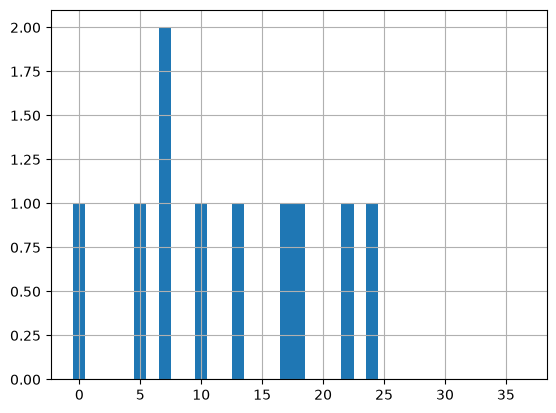

In [81]:
# Distribution of the 10 spins (numbers)
spins_10['number'].hist(bins=np.arange(-0.5, 37.5, 1))

In [89]:
ev = np.mean(european_roulette_wheel['number'])
spins_10_ev = np.mean(spins_10['number'])

print(f'Theoretical Expected Value of the European Roulette Wheel: {ev}')
print(f'Expected Value of the 10 Spins: {spins_10_ev}')

Theoretical Expected Value of the European Roulette Wheel: 18.0
Expected Value of the 10 Spins: 12.3


The expected values of samples is far from the expected value of the wheel

### 3.3.2 Now, sampling 1000 times

In [41]:
# Simulating 1000 spins
spins_1000 = european_roulette_wheel[['number', 'color']].sample(n=1000, replace=True)

In [48]:
# Color distribution of the 1000 spins
spins_1000['color'].value_counts().reset_index()

,color,count
0,red,494
1,black,489
2,green,17


<Axes: >

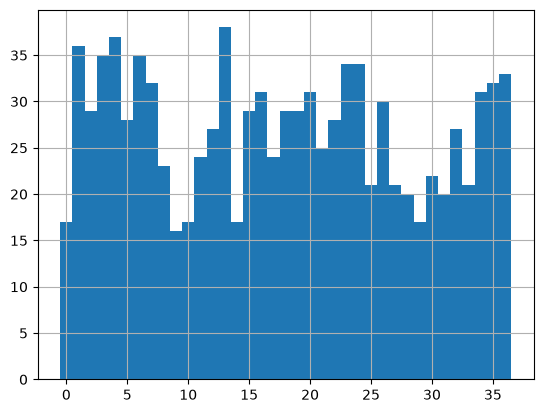

In [80]:
# Distribution of the 1000 spins (numbers)
spins_1000['number'].hist(bins=np.arange(-0.5, 37.5, 1))

In [88]:
spins_1000_ev = np.mean(spins_1000['number'])

print(f'Theoretical Expected Value of the European Roulette Wheel: {ev}')
print(f'Expected Value of the 10000 Spins: {spins_1000_ev}')

Theoretical Expected Value of the European Roulette Wheel: 18.0
Expected Value of the 10000 Spins: 17.634


The Expected Value of 1000 spins is closer to 18.0 

Also, the distribution is closer to a uniform distribution

### 3.3.3 Now, 10K samples

In [66]:
# Simulating 10000 spins
spins_10k = european_roulette_wheel[['number', 'color']].sample(n=10000, replace=True)

In [67]:
# Color distribution of the 1000 spins
spins_10k['color'].value_counts().reset_index()

,color,count
0,red,4912
1,black,4814
2,green,274


<Axes: >

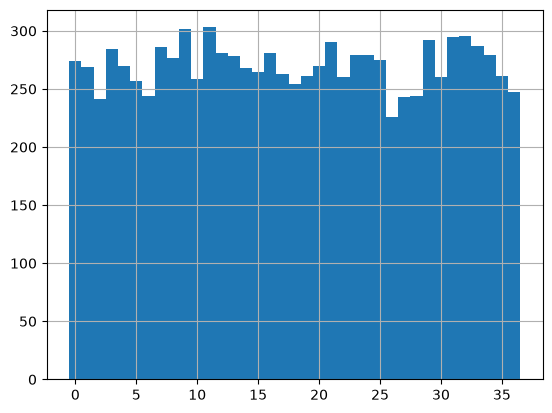

In [82]:
# Distribution of the 10000 spins (numbers)
spins_10k['number'].hist(bins=np.arange(-0.5, 37.5, 1))

In [90]:
spins_10k_ev = np.mean(spins_10k['number'])

print(f'Theoretical Expected Value of the European Roulette Wheel: {ev}')
print(f'Expected Value of the 10000 Spins: {spins_10k_ev}')

Theoretical Expected Value of the European Roulette Wheel: 18.0
Expected Value of the 10000 Spins: 17.9838


The EV is very close to 18, and the distribution is almost uniform

## 3.3.4 Law of the Large Numbers

The law of large numbers is a theorem in probability and statistics stating that as a sample size grows, its average gets closer to the true average of the whole population. 

In [91]:
lln_df = pd.DataFrame({
    'Samples': [10, 1000, 10000],
    'Expected Value': [spins_10_ev, spins_1000_ev, spins_10k_ev]
})

lln_df

,Samples,Expected Value
0,10,12.3000
1,1000,17.6340
2,10000,17.9838


# 4. Experiment

**How does this affect of influences our chances/odds of winning?**

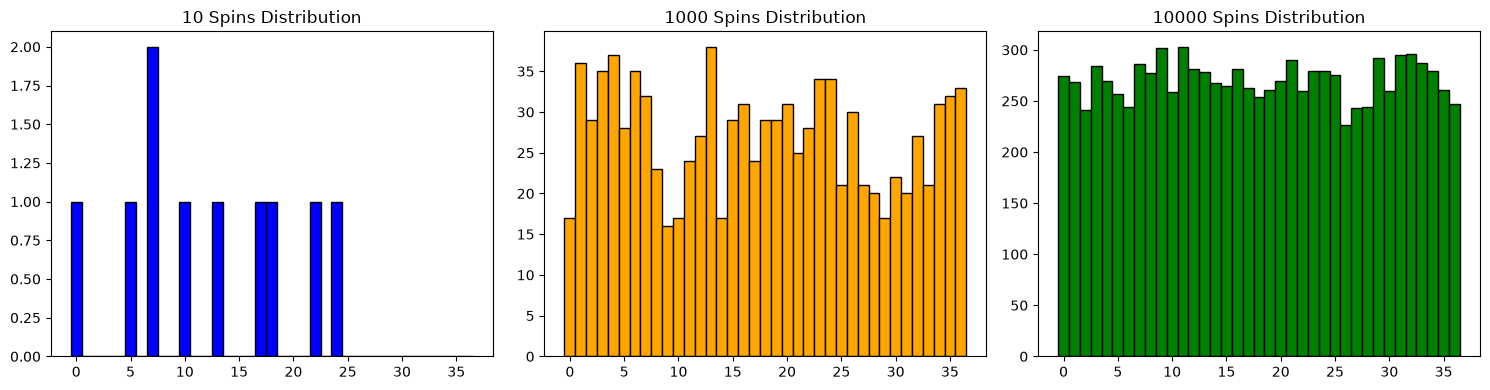

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

mis_bins = np.arange(-0.5, 37.5, 1)

axes[0].hist(spins_10['number'], bins=mis_bins, color='blue', edgecolor='black')
axes[0].set_title('10 Spins Distribution')

axes[1].hist(spins_1000['number'], bins=mis_bins, color='orange', edgecolor='black')
axes[1].set_title('1000 Spins Distribution')

axes[2].hist(spins_10k['number'], bins=mis_bins, color='green', edgecolor='black')
axes[2].set_title('10000 Spins Distribution')

plt.tight_layout()
plt.show()